DIFFERENZE TRA AUOTENCODER E MODELLI GENERATIVI: GAN e VAE

Un autoencoder standard standard è un ottimo archivista ma un pessimo artista.
Immagina la differenza tra una fotocopiatrice ed un pittore.
La fotocopiatrice riproduce ciò che vede, ma se gli chiedi in inventare un paesaggio nuovo non sa da dove iniziare.

Il determinisco è una gabbia.
Mentra la stocasticità è la chiave dell'invenzione/creatività.

Autoencoder classico = ricostruire bene ciò che ha visto
VAE e GAN = generare nuovi esempi plausibili
L'obbiettivo pertanto è diverso
Autoencoder classico:
immagine x -> encoder -> z -> decoder -> immagine x ricostruita
L'obbiettivo è partire da x e ottenere qualcosa di simile a x
La loss è l'MSE
Quindi il modello viene premiato se ricostruisce bene
Il problema è che quello spazio latente z, non è necessariamente ben organizzato, potrebbe esserci una zona dello spazio latente che il decoder non ha mai imparato bene
Ed è per questo che un autoencoder classico non è, in senso stretto, un vero modello generativo.

Ora arriva il VAE (Variational Autoencoder)
La struttura assomiglia molto all'autoencoder:
x -> encoder -> spazio latente -> decoder -> qualcosa di simile a x
ma c'è una differenza decisiva.
L'encoder non produce direttamente un univo vettore z
Produce i parametri di una distribuzione mu e sigma
Però non è tutto
Il VAE cerca anche di organizzare tutte queste distribuzioni latenti in modo che assomiglino a una distribuzione semplice

Perchè un autoencoder standard fallisce come generatore?
Dalla ricostruzione puntuale alla modellazione di distribuzioni
Autoencoder standard comprime i dati. il loro limite risiede nella natura deterministica del mapping tra input e spazio latente.
Un modello progettato per la sola ricostruzione fallisce nel compito di creare campioni nuovi e coerenti.
Passare alla generazione significa di smettere di mappare punti e inziare a modellare distribuzioni.
Non vogliamo più un punto ma un'area di probabilità
Questa rigidità crea un problema geografico nello spazio delle feature

La discontinuità dello spazio latente
Il problema dei buchi nello spazio delle feature.
- In un AE strandard, l'encoder mappa un input in un singolo punto discreto dello spazio latente senza alcuna restrizione sulla sua distribuzione
- Lo spazio latente risulta non regolare: punti vicini nello spazio non corrispondono necessariamente a dati semanticamente simili.
- Campionando in zone non visitate durante il training, il decode produce output privi di senso, definiti spesso come rumore o artefatti.
- Il passaggio fondamentale verso i modelli generativi consiste nel trasformare questo mapping deterministico in un processo probabilistico.

Ma perchè la nostra funzione di perdita non ci aiuta a riempire questi buchi?

Limiti della Reconstruction Loss
- Overfitting Latente: senza regolarizzazione, l'AE memorizza i dati di input come coordinate isolate invece di imparare la struttura della varietà sottostante. L'errore quadratico medio (MSE) è servero che vuole solo una cosa 'la fedeltà assoluta al pixel originale'. Questo porta all'overfitting latente, cioè impara coordinate isolate invece di capire la struttira profonda dei dati.
- Assenza di Prior: non conoscendo la distribuzione dei vettori z, non esiste un modo sistematico per campionare nuovi dati del bottleneck
- Interpolazione Incoerente: muoversi tra due punti latenti validi in un AE porta spesso attraverso territori di bassa probabilità che non corrispondono a dati reali.

Dall'identità alla Generazione
Perchè ci serve la probabilità?
Dobbiamo assicurarci che lo spazio latente non sia un oceano vuoto, ma un continente solido e continuo. dove ogni coordinata, anche quella mai vista prima, corrisponda a qualcosa di reale.
Vogliamo che se ci muoviamo di 1mm nello spazio latente, l'immagine cambi di 1mm dalla realtà.
Dobbiamo passare da un z nota, a una distribuzione di z che possiamo controllare.
Per generare, dobbiamo assicurarci che l'intero spazio latente sia popolato in modo denso e organizzato, permettendo al decoder di interpretare ogni coordinata.
Questo ci porta a esplorare due filosofie diverse:
- la competizione avversaria delle GAN
- la regolarizzazione bayesiana dei VAE

La prima rivoluzione è arrivato con un approccio quasi brutale, la competizione

Approccio GAN
Generative Adversarial Networks e la teorica dei giochi
Le GAN abbandonano il concetto di errore di ricostruzione esplicito per adottare una strategia di addestramento basata sulla competizione tra due reti neurali.
L'equilibrio dinamico permette di generare immagini con un livello di dettaglio e nitidezza superiore ai modelli basati su medi statistiche.
Qui non cerchiamo di copiare, le GAN si basano sulla teoria dei giochi.
Immagina due persone:
- un falsario che cerca di stampare banconote perfette
- e un poliziotto che devo scovarlo
questa lotta continua spinge il falsario a diventare sempre più bravo, non perchè voglia copiare una banconota specifica ma perchè vuole che il suo lavoro sia indistinguibile dalla realtà.

Questa sfida si traduce in architettura neurale

Il gioco Min-Max
Generatore contro Discriminatore
- Il generatore tenta di mappare rumore casuale in campioni realistici per ingannare la rete avversarie. Trasforma il rumore casuale in immagini
- Il Discriminatore agisce come un critico, imparando a distinguere tra dati reali del datasete e dati sintetici prodotti dal generatore.
- L'addestramento non cerca un minimo globale di una loss fissa, ma un equilibrio di Nash in un sistema dinamico
- A differenza degli AE, le GAN non calcolano mai una verosomiglianza esplicita, agendo come modelli generativi impliciti.
Il generatore vince quando il discriminatore deve tirare ad indovinare con  una probabilità del 50%

Non calcoliamo mai quanto è probabile un pixel, lasciamo che sia la competizione a guidare la rete verso la verosomiglianza

Addestrare una GAN è come cercare di bilanciare due matite sulle punte una dell'altra
Se il discriminatore diventa troppo bravo troppo presto, il discriminatore si scoraggio e smette di imparare. Se il generatore trova un trucco per ingannare un critico, inizia a produrre la stessa immagine.
Inoltre le GAN sono famose per la loro capriciosittà durante il training, basta un parametro sbagliato perchè tutto il sistema crolli
nonostante tutto il risultato visivo è enorme.

Mentre un AE cerca di ricreare esattamente l'input, una GAN cerca di ricreare lo stile e la distribuzione, ignorando la corrispondenza pixel per pixe.
Questa libertà permette alle GAN di essere creative, ma le rende difficili da usare quando la precisione della ricostruzione è fondamentale.

Ma se volessimo la nitidezza delle GAN ed il controllo strutturale degli autoencoder?

E' così che entrano in gioco i VAE

Approccio VAE
Variational Autoencoders e la regolarizzazione latente.
I VAE rappresentano il ponte perfetto: mantengono l'architettura encoder-decoder ma introducono rigorosi vincoli probabilistici nello spazio latente.
L'idea è semplice, invece di mappare un input in un punto, lo mappiamo in una nuvola di probabilità. In questo modo forziamo lo spazio latente ad essere ordinato, denso e soprattutto, continuo.

Distribuzione Latenti e KL Divergence
Mappare dati in parametri di una distribuzione
- L'encoder di un VAE non restituisce un vettore fiso, ma i parametri di una distribuzione: media e varianza.
- La funzione di perdita include la Divergenza di Kullaback-Leibler per minimizzare la distanza tra la distribuzione appresa e una prior nota. 
- Il campionamente avviene tramite il Raparameterization Trick, permettendo al gradiente di fluire attraverso stati stocastici.
- Questa regolarizzazione garantisce uno spazio latente continuo e completo, ideale per generare nuovi dati tramite interpolazione.

VAE vs AE Standard
La differenza è la continuita semantica. A parità di input l'encoder di un VAE produce ogni volta un codice latente leggermente diverso, aumentando la robustezza del decoder (stocasticità nell'Encoder).
Grazie alla KL Loss zone vicine nello spazio latente codificano necessariamente variazioni coerenti del dato originlae (continuità semantica)
A causa dell'approccio statistico basato sulla media, le ricostruzioni dei VAE tendono ad essere meno nitide rispetto a quelle prodotte dalle GAN.

Logica di Implementazione
Dalla teoria al codice
Quando definiamo una funzione VAE dobbiamo stare attenti a come definiamo la funzione di perdita custom.
Non è più solo MSE, è un equilibrio tra ricostruzione e regolarizzazione.
Il risultato è uno spazio latente dove i dati sono organizzati in spazi circolari pronti per essere esplorati.

Caricamento dataset MNIST...
Inizio addestramento (10 epoche)...
Allenamento Autoencoder Standard in corso...
Allenamento Variational Autoencoder in corso...
Generazione dei grafici dello spazio latente...


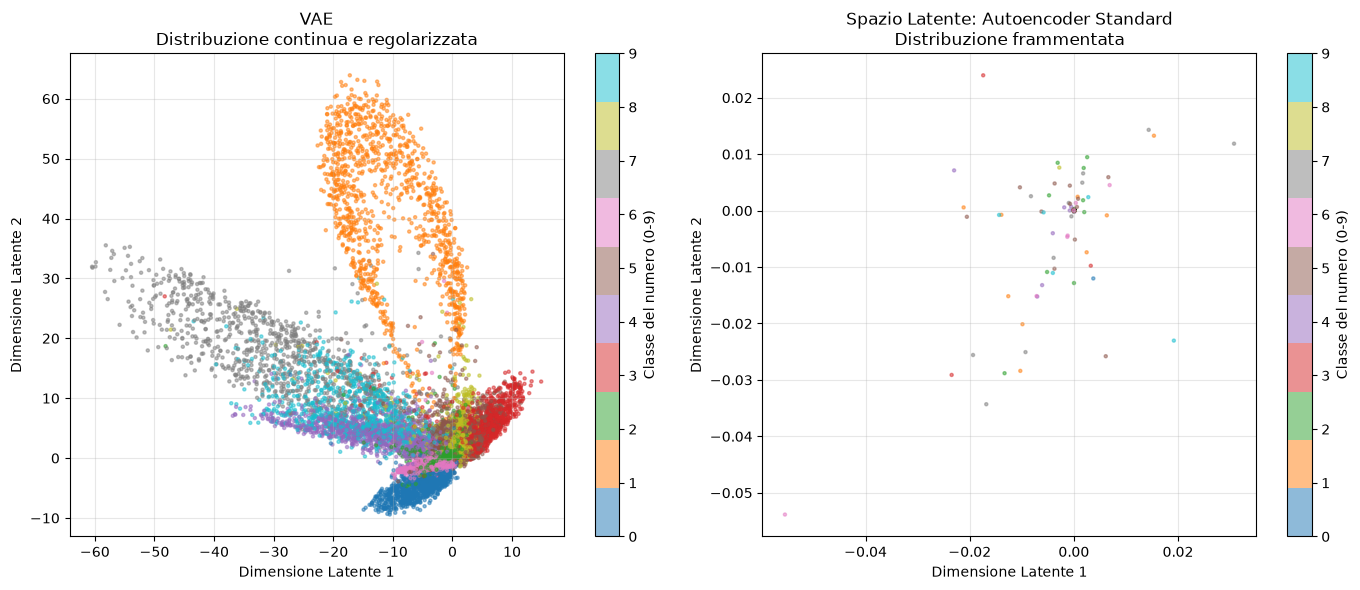

In [1]:
import os

# 1. SETUP DELL'AMBIENTE DI CALCOLO
# Impostiamo il backend di Keras su PyTorch. Questa configurazione deve avvenire
# prima di importare Keras per garantire che il motore computazionale sia quello desiderato.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import matplotlib.pyplot as plt

# --- 2. PREPARAZIONE DEL DATASET MNIST ---
# Il dataset MNIST contiene 70.000 immagini in scala di grigi di cifre (0-9) da 28x28 pixel.
print("Caricamento dataset MNIST...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizzazione: I valori dei pixel (0-255) vengono portati nel range [0, 1].
# Questo facilita la convergenza dell'ottimizzatore durante l'addestramento.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Appiattimento (Flattening): Trasformiamo la matrice 28x28 in un vettore monodimensionale di 784 elementi.
# Questo è necessario perché utilizzeremo layer densi (fully connected) che accettano vettori.
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

# --- 3. ARCHITETTURA: AUTOENCODER STANDARD (AE) ---
# L'Autoencoder "comprime" l'input in uno spazio a bassa dimensionalità e poi tenta di ricostruirlo.
# Non ha vincoli sulla forma dello spazio latente, che spesso risulta disorganizzato.

# Input: Riceve i 784 pixel dell'immagine appiattita.
inputs_ae = keras.Input(shape=(784,))

# Encoder: Riduce la dimensionalità a 64 e poi a 2 (spazio latente).
encoded_ae = layers.Dense(64, activation="relu")(inputs_ae)  
latent_ae = layers.Dense(2, name="Latent_Space_AE")(encoded_ae) 

# Decoder: Prende il punto nel piano 2D e cerca di rigenerare i 784 pixel originali.
decoded_ae = layers.Dense(64, activation="relu")(latent_ae)
outputs_ae = layers.Dense(784, activation="sigmoid")(decoded_ae) 

# Modello AE: Collega input e output.
model_ae = keras.Model(inputs_ae, outputs_ae, name="Autoencoder_Standard")
model_ae.compile(optimizer="adam", loss="mse")

# --- 4. ARCHITETTURA: VARIATIONAL AUTOENCODER (VAE) ---
# A differenza dell'AE, il VAE mappa l'input in una distribuzione di probabilità (media e varianza).
# Questo costringe lo spazio latente a essere continuo e organizzato (simile a una Gaussiana).

# Layer personalizzato per la KL Divergence.
# In Keras 3, aggiungere una loss interna richiede un layer che utilizzi self.add_loss().
class KLLossLayer(layers.Layer):
    """
    Questo layer calcola la divergenza di Kullback-Leibler, che penalizza
    le distribuzioni latenti che si allontanano troppo da una normale standard (0, 1).
    """
    def call(self, inputs):
        z_mean, z_log_var = inputs
        # Formula matematica: -0.5 * sum(1 + log_var - mean^2 - exp(log_var))
        # Questa perdita agisce come regolarizzatore dello spazio latente.
        loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
        loss = ops.mean(ops.sum(loss, axis=1)) 
        self.add_loss(loss) 
        return inputs 

# Encoder VAE: Produce due vettori, media (mu) e log-varianza (log_var).
inputs_vae = keras.Input(shape=(784,))
h_vae = layers.Dense(64, activation="relu")(inputs_vae)
z_mean = layers.Dense(2, name="z_mean")(h_vae)
z_log_var = layers.Dense(2, name="z_log_var")(h_vae)

# Applichiamo il layer della Loss KL per registrare la regolarizzazione nel grafo del modello.
z_mean, z_log_var = KLLossLayer()([z_mean, z_log_var])

# Reparameterization Trick: Permette la backpropagation attraverso un campionamento stocastico.
# Invece di campionare direttamente da N(mu, sigma), campioniamo epsilon da N(0, 1) 
# e calcoliamo: z = mu + sigma * epsilon.
def sampling(args):
    mean, log_var = args
    epsilon = keras.random.normal(shape=ops.shape(mean))
    return mean + ops.exp(0.5 * log_var) * epsilon

# Il layer Lambda esegue la funzione di campionamento durante il passaggio in avanti.
z = layers.Lambda(sampling, output_shape=(2,))([z_mean, z_log_var])

# Decoder VAE: Ricostruisce l'immagine a partire dal punto campionato 'z'.
dec_h = layers.Dense(64, activation="relu")(z)
outputs_vae = layers.Dense(784, activation="sigmoid")(dec_h)

# Modello VAE: La loss totale sarà la somma di MSE (ricostruzione) + KL (regolarizzazione).
model_vae = keras.Model(inputs_vae, outputs_vae, name="VAE")
model_vae.compile(optimizer="adam", loss="mse")

# --- 5. FASE DI ADDESTRAMENTO ---
# Entrambi i modelli cercano di minimizzare l'errore tra input e output (auto-supervisione).
print("Inizio addestramento (10 epoche)...")
epochs = 10
batch_size = 128

# Addestriamo l'AE
print("Allenamento Autoencoder Standard in corso...")
model_ae.fit(x_train, x_train, epochs=epochs, batch_size=batch_size, verbose=0)

# Addestriamo il VAE
print("Allenamento Variational Autoencoder in corso...")
model_vae.fit(x_train, x_train, epochs=epochs, batch_size=batch_size, verbose=0)

# --- 6. ANALISI E VISUALIZZAZIONE DELLO SPAZIO LATENTE ---
# Estraiamo solo la parte "Encoder" di entrambi i modelli per vedere come raggruppano i dati.
print("Generazione dei grafici dello spazio latente...")

# Sottomodelli per l'estrazione delle coordinate 2D
encoder_ae = keras.Model(inputs_ae, latent_ae)
encoder_vae = keras.Model(inputs_vae, z_mean) # Per il VAE usiamo la media come coordinata rapida

# Trasformiamo i dati di test (mai visti prima) in coordinate 2D
z_ae = ops.convert_to_numpy(encoder_ae.predict(x_test, verbose=0))
z_vae = ops.convert_to_numpy(encoder_vae.predict(x_test, verbose=0))

# Creazione della figura comparativa
plt.figure(figsize=(14, 6))

# Grafico 1: Autoencoder Standard
# Noterete buchi e cluster molto distanti; lo spazio non è pensato per la generazione.
plt.subplot(1, 2, 1)
plt.scatter(z_ae[:, 0], z_ae[:, 1], c=y_test, cmap="tab10", alpha=0.5, s=5)
plt.colorbar(label="Classe del numero (0-9)")
plt.title("VAE\nDistribuzione continua e regolarizzata")
plt.xlabel("Dimensione Latente 1")
plt.ylabel("Dimensione Latente 2")
plt.grid(True, alpha=0.3)

# Grafico 2: Variational Autoencoder
# Noterete una distribuzione più compatta e centrata; ideale per campionare nuovi dati.
plt.subplot(1, 2, 2)
plt.scatter(z_vae[:, 0], z_vae[:, 1], c=y_test, cmap="tab10", alpha=0.5, s=5)
plt.colorbar(label="Classe del numero (0-9)")
plt.title("Spazio Latente: Autoencoder Standard\nDistribuzione frammentata")
plt.xlabel("Dimensione Latente 1")
plt.ylabel("Dimensione Latente 2")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()